# Phase Shift Gates ($S, S^\dagger, T, T^\dagger$)

### The S Gate
* **Operation:** Applies a $\frac{\pi}{2}$ radian ($90^\circ$) phase shift via a quarter-turn rotation around the Z-axis.
* **Geometric Effect:** Rotates the $|+\rangle$ state (positive X-axis) to the $|+i\rangle$ state (positive Y-axis).
* **Matrix Representation:** Available in standard and exponential formats:

$$S = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\frac{\pi}{2}} \end{bmatrix}$$

* **Action on $|+\rangle$:**
$$S|+\rangle = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix} \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{1}{\sqrt{2}} \end{bmatrix} = \begin{bmatrix} \frac{1}{\sqrt{2}} \\ \frac{\color{darkcyan}i}{\sqrt{2}} \end{bmatrix} = |+i\rangle$$

---

### Algebraic Properties & Identities

#### Non-Self-Inverse ($S^2 = Z$)
* Unlike the Pauli gates, the $S$ gate is not its own inverse.
* Applying $S$ twice results in a $\pi$ radian ($180^\circ$) half-turn rotation around the Z-axis, which is equivalent to a Pauli-Z gate:

$$S^2 = S \cdot S = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} = Z$$

#### The $S^\dagger$ (S-Dagger) Gate
* **Operation:** Applies a $-\frac{\pi}{2}$ radian ($-90^\circ$) phase shift.
* **Efficiency Note:** Shifting phase by $\frac{3\pi}{2}$ ($270^\circ$) via $S^3$ is logically equivalent to a single $S^\dagger$ rotation in the opposite direction.
* **Matrix Representation:** The conjugate transpose of the regular $S$ gate matrix:

$$S^\dagger = \begin{bmatrix} 1 & 0 \\ 0 & -i \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & e^{-i\frac{\pi}{2}} \end{bmatrix}$$

* **Inverse Identity:** Back-to-back operations cancel out to yield the identity matrix ($I$):

$$S \cdot S^\dagger = \begin{bmatrix} 1 & 0 \\ 0 & i \end{bmatrix} \begin{bmatrix} 1 & 0 \\ 0 & -i \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} = I$$

---

### The T and $T^\dagger$ Gates
* **Operation:** Shift the relative phase by $\pm\frac{\pi}{4}$ radians ($45^\circ$, or an eighth of a turn) around the Z-axis.
* **Matrix Representation:**

$$T = \begin{bmatrix} 1 & 0 \\ 0 & e^{i\frac{\pi}{4}} \end{bmatrix} \qquad T^\dagger = \begin{bmatrix} 1 & 0 \\ 0 & e^{-i\frac{\pi}{4}} \end{bmatrix}$$

* **Square Root Property:** The $T$ gate acts as the geometric square root of the $S$ gate ($T^2 = S$).

---

### Phase Gates Summary

| Gate | Name | Z-Axis Rotation | Exponential Matrix Format | Inverse Gate |
| :--- | :--- | :--- | :--- | :--- |
| **$S$** | Phase Gate | $+\pi/2$ ($90^\circ$) | $\begin{bmatrix} 1 & 0 \\ 0 & e^{i\pi/2} \end{bmatrix}$ | $S^\dagger$ |
| **$S^\dagger$** | Anti-Phase Gate | $-\pi/2$ ($-90^\circ$) | $\begin{bmatrix} 1 & 0 \\ 0 & e^{-i\pi/2} \end{bmatrix}$ | $S$ |
| **$T$** | $\pi/8$ Gate | $+\pi/4$ ($45^\circ$) | $\begin{bmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{bmatrix}$ | $T^\dagger$ |
| **$T^\dagger$** | Anti-$\pi/8$ Gate | $-\pi/4$ ($-45^\circ$) | $\begin{bmatrix} 1 & 0 \\ 0 & e^{-i\pi/4} \end{bmatrix}$ | $T$ |


In [12]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

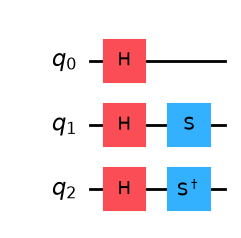

In [13]:
circuit = QuantumCircuit(3)
circuit.h([0,1,2])
circuit.s(1) #Apply S Gate
circuit.sdg(2) #Apply S-dagger Gate
circuit.draw(output='mpl')

In [14]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

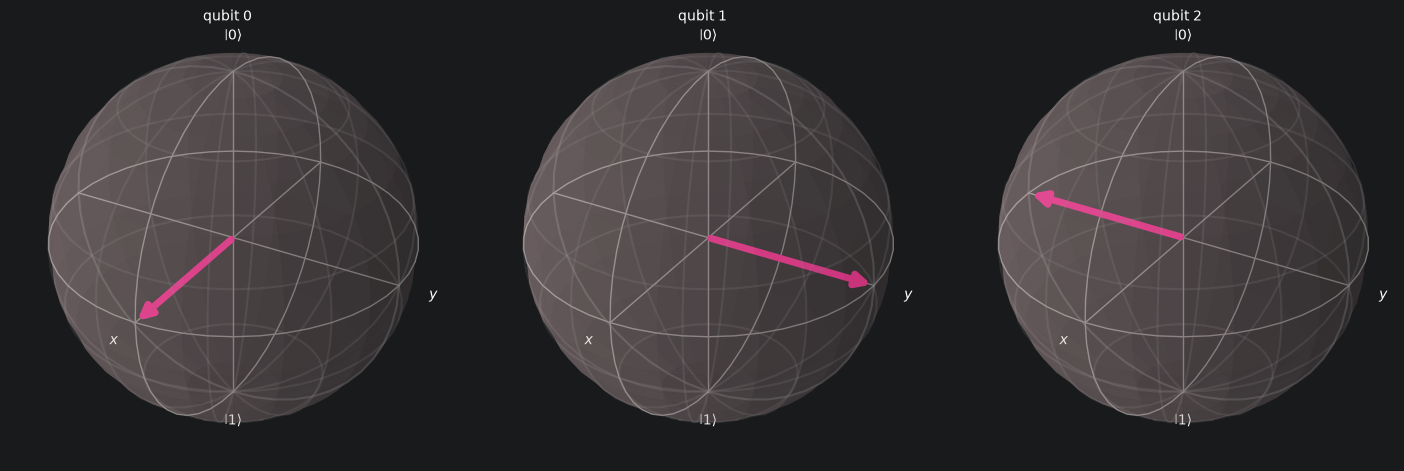

In [15]:
plot_bloch_multivector(statevector)

### Visual Tracking of Phase Shifts S and $S^\dagger$ Gates
* **Initial State:** All three qubits begin in identical starting states.
* **S Gate Impact (Middle Qubit):** Applies a $+\frac{\pi}{2}$ radian phase shift, rotating the state vector $90^\circ$ counterclockwise around the Z-axis.
* **$S^\dagger$ Gate Impact (Right Qubit):** Applies a $-\frac{\pi}{2}$ radian phase shift, rotating the state vector $90^\circ$ clockwise around the Z-axis.


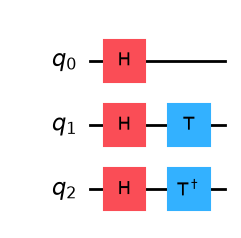

In [16]:
circuit = QuantumCircuit(3)
circuit.h([0, 1, 2])
circuit.t(1)  #Apply S Gate
circuit.tdg(2)  #Apply S-dagger Gate
circuit.draw(output='mpl')

In [17]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

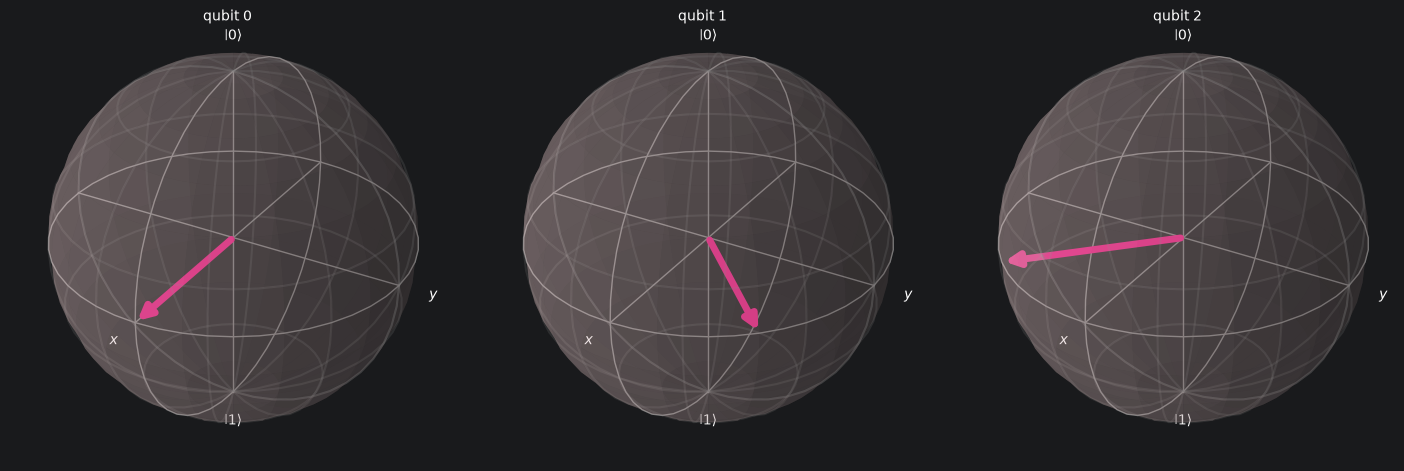

In [18]:
plot_bloch_multivector(statevector)

### Visual Tracking of Phase Shifts T and $T^\dagger$ Gates
* **Initial State:** All three qubits begin in identical starting states.
* **T Gate Impact (Middle Qubit):** Applies a $+\frac{\pi}{4}$ radian phase shift, rotating the state vector $45^\circ$ counterclockwise around the Z-axis (half the rotation of an $S$ gate).
* **$T^\dagger$ Gate Impact (Right Qubit):** Applies a $-\frac{\pi}{4}$ radian phase shift, rotating the state vector $45^\circ$ clockwise around the Z-axis.
* **Application Note:** The $S$ and $T$ families of gates serve as the standard quantum toolkit for precise, discrete phase shifts along the Z-axis.
